In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from models import train_linear_model, train_logistic_model
from sklearn.metrics import accuracy_score

# Load dataset
relative_path = "data/student_portugal/student_por_processed.csv"
data_file = os.path.join(os.getcwd(), relative_path)
df = pd.read_csv(data_file)
print("Loaded datafile")

# Ensure all rows are unique
df = df.drop_duplicates()
print("Removed duplicate rows")

# Split into training and testing sets (85% training, 15% testing)
#train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)
#print("Data split into training and testing sets")

Using device: cpu
Loaded datafile
Removed duplicate rows
Data split into training and testing sets


In [2]:
def split_dataframe(df: pd.DataFrame, condition: str):
    """
    Splits a DataFrame into two based on a given condition.
    
    Parameters:
        df (pd.DataFrame): The input dataframe.
        condition (str): A condition string that can be evaluated with `query`.
        
    Returns:
        tuple: Two dataframes, one meeting the condition and one not meeting it.
    """
    try:
        df_matching = df.query(condition)
        df_not_matching = df[~df.index.isin(df_matching.index)]
        return df_matching, df_not_matching
    except Exception as e:
        print(f"Error evaluating condition: {e}")
        return None, None

In [3]:
def balanced_train_test_split(df_matching: pd.DataFrame, df_not_matching: pd.DataFrame, split_ratio: float):
    """
    Splits the matching dataframe into training and testing sets and balances them with non-matching entries.
    
    Parameters:
        df_matching (pd.DataFrame): The dataframe meeting the condition.
        df_not_matching (pd.DataFrame): The dataframe not meeting the condition.
        split_ratio (float): The proportion of df_matching to be used for training.
        
    Returns:
        tuple: Two balanced dataframes - training set and testing set.
    """
    try:
        train_matching, test_matching = train_test_split(df_matching, test_size=(1 - split_ratio), random_state=42)
        
        train_size = len(train_matching)
        test_size = len(test_matching)
        
        train_non_matching = df_not_matching.sample(n=train_size, random_state=42, replace=False)
        remaining_non_matching = df_not_matching.drop(train_non_matching.index)
        test_non_matching = remaining_non_matching.sample(n=test_size, random_state=42, replace=False)
        
        train_balanced = pd.concat([train_matching, train_non_matching]).sample(frac=1, random_state=42)
        test_balanced = pd.concat([test_matching, test_non_matching]).sample(frac=1, random_state=42)
        
        return train_balanced, test_balanced
    except Exception as e:
        print(f"Error during balancing: {e}")
        return None, None

In [4]:
failures, no_failures = split_dataframe(df, "failures > 0")
train_balanced, test_balanced = balanced_train_test_split(failures, no_failures, 0.80)

In [5]:
# Define features and target variable
X_train = train_balanced.drop(columns=['failures']).values
y_train_reg = train_balanced['failures']
y_train_cls = (train_balanced['failures'] > 0).astype(int)

X_test = test_balanced.drop(columns=['failures']).values
y_test_reg = test_balanced['failures']
y_test_cls = (test_balanced['failures'] > 0).astype(int)

regularizer_weight = 0.01  # Regularization strength

print("Classifier identified")

Classifier identified


In [6]:

# Train regression models
print("Training RegN")
model1 = train_linear_model(X_train, y_train_reg.values, reg_type=None)  # Standard
print("Training Reg1")
model2 = train_linear_model(X_train, y_train_reg.values, reg_type="l1", alpha=regularizer_weight)  # Lasso
print("Training Reg2")
model3 = train_linear_model(X_train, y_train_reg.values, reg_type="l2", alpha=regularizer_weight)  # Ridge

# Train logistic models
print("Training LogN")
model4 = train_logistic_model(X_train, y_train_cls.values, reg_type=None)  # Standard
print("Training Log1")
model5 = train_logistic_model(X_train, y_train_cls.values, reg_type="l1", alpha=regularizer_weight)  # Lasso
print("Training Log2")
model6 = train_logistic_model(X_train, y_train_cls.values, reg_type="l2", alpha=regularizer_weight)  # Ridge


Training RegN
Training Reg1
Training Reg2
Training LogN
Training Log1
Training Log2


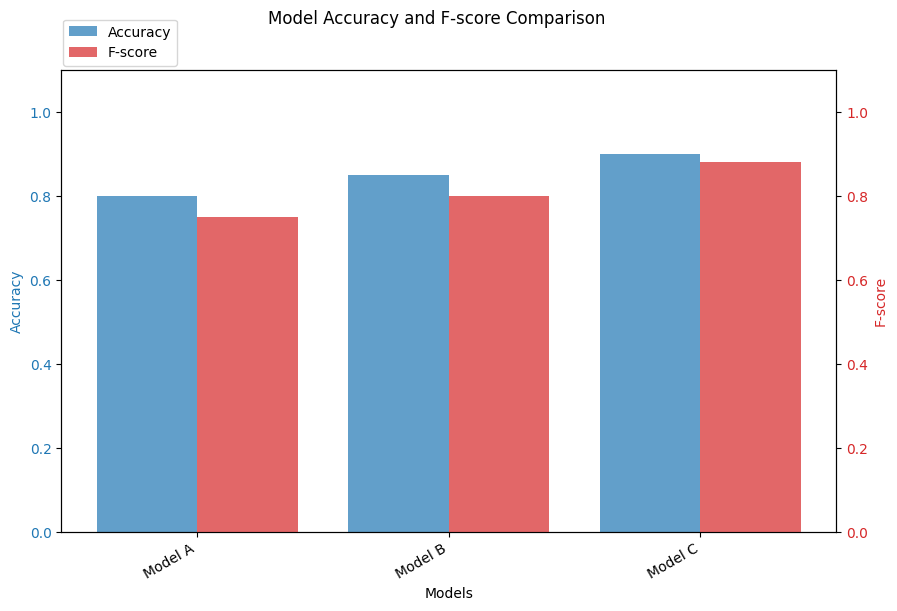

Evaluating models
Regression Models:


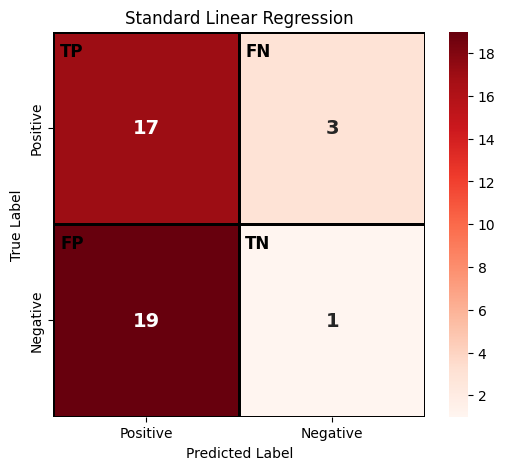

Standard Linear Regression accuracy: 0.45
Standard Linear Regression f1 score: 0.6071428571428571


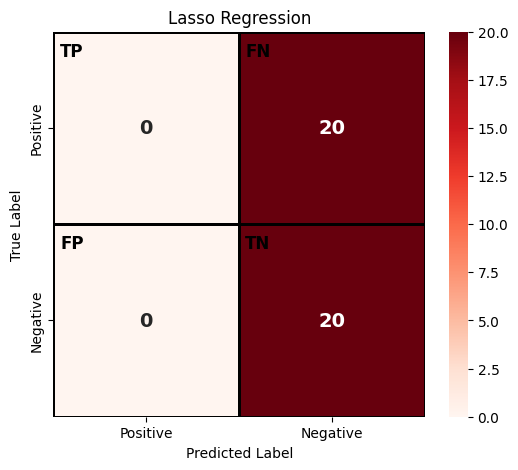

Lasso Regression accuracy: 0.5
Lasso Regression f1 score: 0


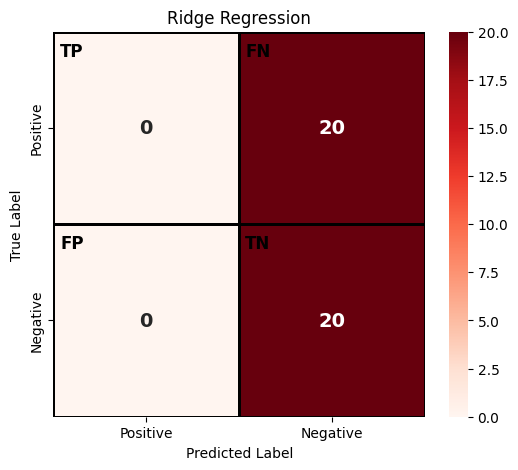

Ridge Regression accuracy: 0.5
Ridge Regression f1 score: 0
Logistic Models:


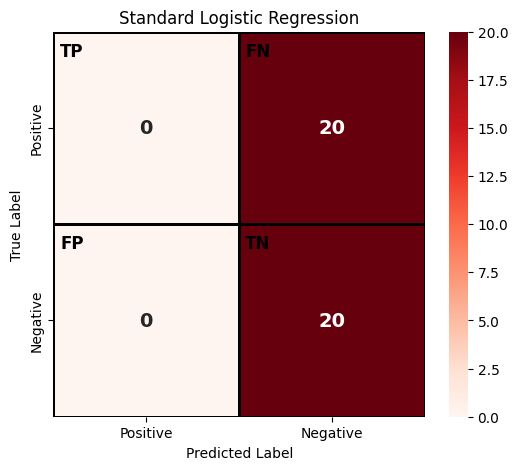

Standard Logistic Regression accuracy: 0.5
Standard Logistic Regression f1 score: 0


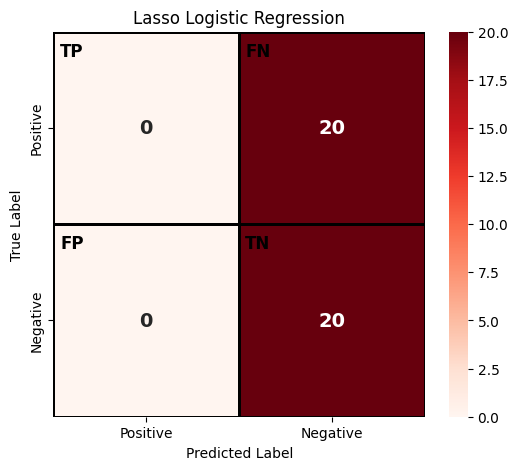

Lasso Logistic Regression accuracy: 0.5
Lasso Logistic Regression f1 score: 0


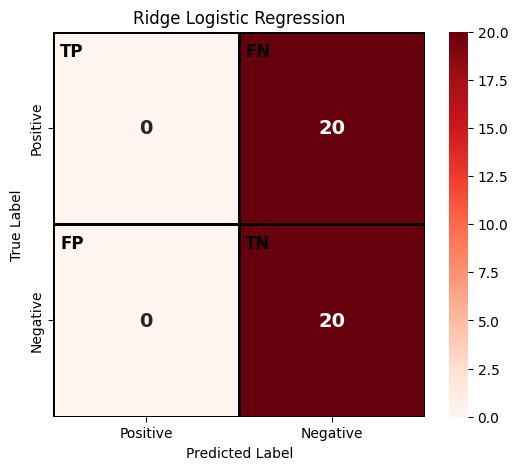

Ridge Logistic Regression accuracy: 0.5
Ridge Logistic Regression f1 score: 0


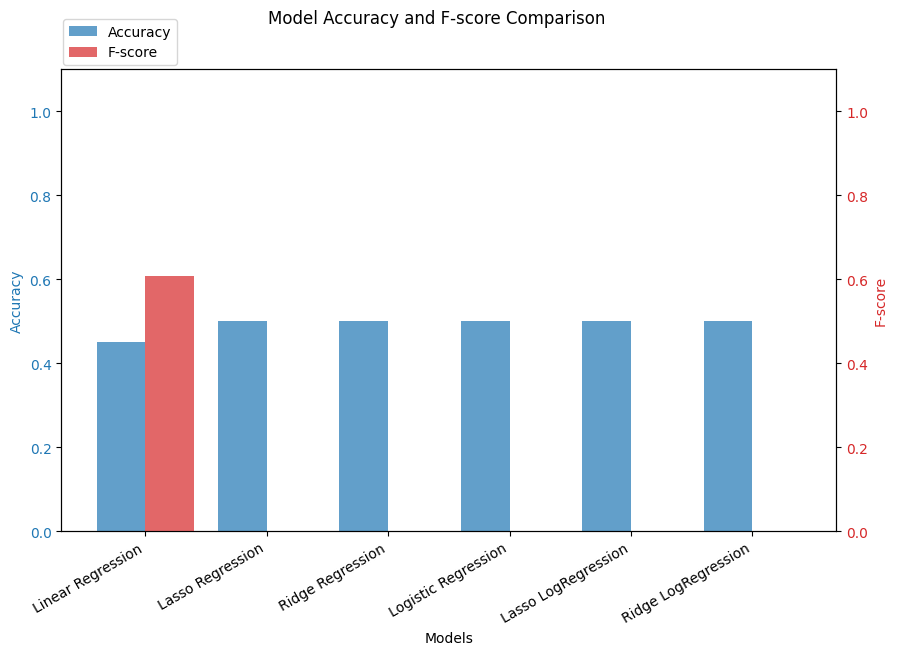

In [7]:
from evaluation import plot_confusion_matrix, fscore
# Testing Section
print("Evaluating models")

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test) > 0
    acc = accuracy_score(y_test, y_pred)
    f1 = fscore(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred, model_name)
    print(f"{model_name} accuracy: {acc}")
    print(f"{model_name} f1 score: {f1}")
    return acc, f1
    

# Evaluate regression models
print("Regression Models:")
acc1, f1 = evaluate_model(model1, X_test, (y_test_reg > 0).astype(int), "Standard Linear Regression")
acc2, f2 = evaluate_model(model2, X_test, (y_test_reg > 0).astype(int), "Lasso Regression")
acc3, f3 = evaluate_model(model3, X_test, (y_test_reg > 0).astype(int), "Ridge Regression")

# Evaluate logistic models
print("Logistic Models:")
acc4, f4 = evaluate_model(model4, X_test, y_test_cls, "Standard Logistic Regression")
acc5, f5 = evaluate_model(model5, X_test, y_test_cls, "Lasso Logistic Regression")
acc6, f6 = evaluate_model(model6, X_test, y_test_cls, "Ridge Logistic Regression")

from evaluation import plot_model_acc_and_fscore

accs = [acc1, acc2, acc3, acc4, acc5, acc6]
fscores = [f1, f2, f3, f4, f5, f6]
model_names = ["Linear Regression", "Lasso Regression", "Ridge Regression",
               "Logistic Regression", "Lasso LogRegression", "Ridge LogRegression"]
plot_model_acc_and_fscore(accs, fscores, model_names)

